In [1]:
DATA_PATH = r'/data/project/ARM_Summer_School_2026/data/dpscream/'

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import glob

**Science question(s)**: The upstart DP-SCREAM model is ready to rumble with the long-in-the-tooth WRF model–which one compares better to observations? How do differences in resolution and physics impact cloud representation?


**Project Scope**: We have prepared DP-SCREAM simulations to pair with WRF sims from LASSO-ShCu for three cases. ARM has dozens of measurements that can be used to examine the representativeness of these simulations. Cross compare the two models and put their differences in context with the observations. 


**Datasets**:
- DP-SCREAM (dx=3 km) and WRF (dx=100 m) for 9-Jul-2018, 17-May-2019, & 29-Sep-2019
- sgplassohighfreqobsC1.c1: cloud-base height at 5 stations, LWP, LCL, cloud fraction from KAZR-ARSCL
- sgpcldfraccogs10mC1.c1: cloud fraction from photogrammetry–bye bye bugs!
- sgplassodiagobsmod8C1.m1: various prepared obs like CF from TSI, boundary layer T and Q

**Team Members**: Bill, Hsi-Yen, Yijia Sun, Pappu Paul, Lucia, Emmanuel, Roger, Jing Li, Maggie Powell, Luke Heim, Sining Niu
Github Repository Link: TBD


## DP-Scream (3km) (2018 case)

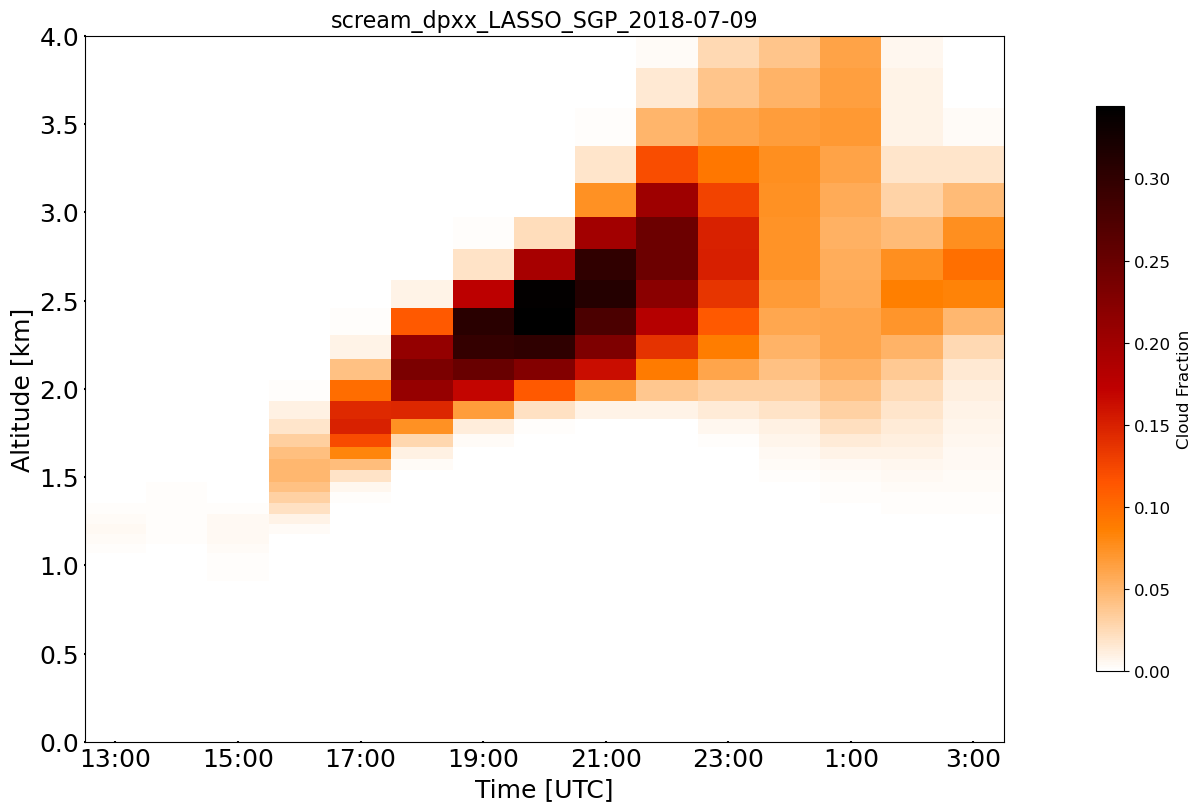

In [15]:
pre_path  = '/pscratch/sd/l/linlin00/DPxx_simulations/LASSO_SGP/'

DATA_PATH = r'/data/project/ARM_Summer_School_2026/data/dpscream/'

case_path = ['scream_dpxx_LASSO_SGP_2018-07-09', 
             'scream_dpxx_LASSO_SGP_2019-05-17', 
             'scream_dpxx_LASSO_SGP_2019-09-29',]

cmap1 = plt.get_cmap('gist_heat_r')

# for acase in case_path:
for acase in [case_path[0]]:
    full_path = DATA_PATH + acase
    data_path = glob.glob(full_path + '*fullfield.AVERAGE.nhours_x1*.nc')[0]

    ncfid     = xr.open_dataset(data_path)
    time      = ncfid['time']
    cf        = ncfid['cldfrac_tot_for_analysis'].mean(dim=['ncol'])
    zmid      = ncfid['z_mid'].mean(dim=['time','ncol']).values/1e3

    fig, ax1 = plt.subplots(1, 1, constrained_layout=True, figsize=(12,8))

    ax1.set_ylabel('Altitude [km]',fontsize=18)
    ax1.set_xlabel('Time [UTC]', fontsize=18)
    ax1.set_title(acase,fontsize=16,loc='center')
    ax1.tick_params(axis='both', which='minor',labelsize=18,length=0,direction='inout',width=1.5,color='k')
    ax1.tick_params(axis='both', which='major',labelsize=18,length=1,direction='inout',width=1.5,color='k')
    ax1.set_ylim([0,4])
    # ax1.set_xlim([0,200])
    ax1.set_yscale('linear')
    ax1.set_xticks(time.values[::2], labels=[str(ii.dt.hour.values)+':'+str(ii.dt.minute.values).zfill(2) for ii in time[::2]])
    
    pm = ax1.pcolormesh(time, zmid, cf.transpose(),shading='auto', cmap=cmap1)

    cb1 = plt.colorbar(pm,ax=ax1, shrink=0.8,location='right', pad=0.1,)
    cb1.ax.tick_params(labelsize=12)
    cb1.set_label(label='Cloud Fraction', fontsize=12)

    ncfid.close()
    plt.show()
    plt.close()

## WRF

In [30]:
WRF_2018_PATH = r'/data/project/ARM_Summer_School_2026/data/dpscream/20180709/sgplassohighfreqobsC1.c1/sgpcldfracset01mC1.c1/data/'

WRF_2018_FILENAME='sgpcldfracset01mC1.c1.20180709.000030.nc'

In [50]:
import pandas as pd
import xarray as xr

WRF_2018 = xr.open_mfdataset(f"{WRF_2018_PATH}*.nc")
WRF_2018

<xarray.Dataset> Size: 41MB
Dimensions:                             (time: 2880, bound: 2, height: 596)
Coordinates:
  * time                                (time) datetime64[ns] 23kB 2018-07-09...
  * height                              (height) float32 2kB 0.16 0.19 ... 18.01
Dimensions without coordinates: bound
Data variables: (12/20)
    base_time                           (time) datetime64[ns] 23kB 2018-07-09...
    time_offset                         (time) datetime64[ns] 23kB dask.array<chunksize=(1440,), meta=np.ndarray>
    time_bounds                         (time, bound) datetime64[ns] 46kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    cloud_fraction_kazrarscl            (time, height) float32 7MB dask.array<chunksize=(1440, 596), meta=np.ndarray>
    cloud_fraction_kazrarscl_fgp        (time, height) float32 7MB dask.array<chunksize=(1440, 596), meta=np.ndarray>
    cloud_fraction_kazrarscl_std        (time, height) float32 7MB dask.array<chunksize=(1440, 596), meta=np.ndarray>
    ...                                  ...
    qc_region_zenith_count              (time) int32 12kB dask.array<chunksize=(1440,), meta=np.ndarray>
    solar_altitude                      (time) float32 12kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_solar_altitude                   (time) int32 12kB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                                 (time) float32 12kB 36.6 36.6 ... 36.6
    lon                                 (time) float32 12kB -97.49 ... -97.49
    alt                                 (time) float32 12kB 318.0 ... 318.0
Attributes: (12/14)
    command_line:          idl -R -n cldfracset -s sgp -f C1 -b 20180709 -R
    Conventions:           ARM-1.2
    process_version:       vap-cldfracset-1.2-0.el6
    dod_version:           cldfracset01m-c1-1.0
    input_datastreams:     sgparsclkazr1kolliasC1.c0 : 1.2 : 20180708.000000-...
    site_id:               sgp
    ...                    ...
    data_level:            c1
    location_description:  Southern Great Plains (SGP), Lamont, Oklahoma
    datastream:            sgpcldfracset01mC1.c1
    averaging_interval:    1 min
    doi:                   10.5439/1523482
    history:               created by user malynn on machine chalk at 2020-02...

In [59]:
WRF_2018.time

<xarray.DataArray 'time' (time: 2880)> Size: 23kB
array(['2018-07-09T00:00:30.000000000', '2018-07-09T00:01:30.000000000',
       '2018-07-09T00:02:30.000000000', ..., '2018-07-10T23:57:30.000000000',
       '2018-07-10T23:58:30.000000000', '2018-07-10T23:59:30.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 23kB 2018-07-09T00:00:30 ... 2018-07-10T23...
Attributes:
    long_name:      Time offset from midnight
    standard_name:  time
    bounds:         time_bounds

In [55]:
WRF_VARNAME = 'cloud_fraction_kazrarscl'

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


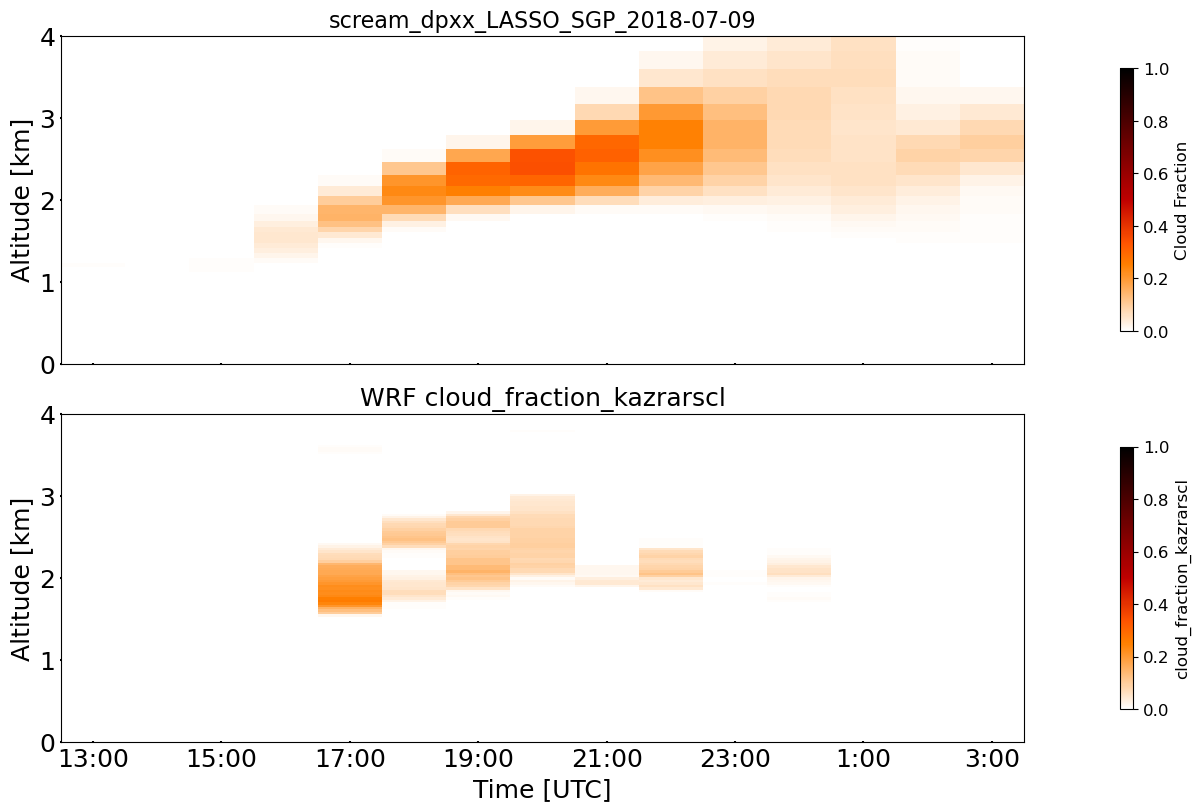

In [63]:
VMIN = 0
VMAX = 1
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    constrained_layout=True,
    figsize=(12, 8),
    sharex=True
)

# =========================
# Top panel (existing plot)
# =========================

ax1.set_ylabel('Altitude [km]', fontsize=18)
ax1.set_title(acase, fontsize=16, loc='center')

ax1.tick_params(
    axis='both',
    which='minor',
    labelsize=18,
    length=0,
    direction='inout',
    width=1.5,
    color='k'
)

ax1.tick_params(
    axis='both',
    which='major',
    labelsize=18,
    length=1,
    direction='inout',
    width=1.5,
    color='k'
)

ax1.set_ylim([0, 4])
ax1.set_yscale('linear')

pm1 = ax1.pcolormesh(
    time,
    zmid,
    cf.transpose(),
    shading='auto',
    vmin = VMIN,
    vmax = VMAX,
    cmap=cmap1
)

cb1 = plt.colorbar(
    pm1,
    ax=ax1,
    shrink=0.8,
    location='right',
    pad=0.1,
)

cb1.ax.tick_params(labelsize=12)
cb1.set_label(label='Cloud Fraction', fontsize=12)

# =========================
# Bottom panel (your DataArray)
# =========================

da = WRF_2018[WRF_VARNAME].sel(time=slice("2018-07-09T13","2018-07-10T03")).resample(time='1H').mean()

ax2.set_ylabel('Altitude [km]', fontsize=18)
ax2.set_xlabel('Time [UTC]', fontsize=18)

ax2.tick_params(
    axis='both',
    which='minor',
    labelsize=18,
    length=0,
    direction='inout',
    width=1.5,
    color='k'
)

ax2.tick_params(
    axis='both',
    which='major',
    labelsize=18,
    length=1,
    direction='inout',
    width=1.5,
    color='k'
)

ax2.set_ylim([0, 4])
ax2.set_yscale('linear')
ax2.set_title(f"WRF {WRF_VARNAME}", fontsize=18)


pm2 = ax2.pcolormesh(
    da['time'],
    da['height'],  
    da.transpose(),
    shading='auto',
    cmap=cmap1,
    vmin = VMIN,
    vmax = VMAX,
)

cb2 = plt.colorbar(
    pm2,
    ax=ax2,
    shrink=0.8,
    location='right',
    pad=0.1,
)

cb2.ax.tick_params(labelsize=12)
cb2.set_label(label=f"{WRF_VARNAME}", fontsize=12)

# =========================
# Shared x ticks
# =========================

ax2.set_xticks(
    time.values[::2],
    labels=[
        str(ii.dt.hour.values) + ':' +
        str(ii.dt.minute.values).zfill(2)
        for ii in time[::2]
    ]
)

plt.show()
plt.close()